In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.table import Table
from astropy.nddata import extract_array
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.wcs.utils import skycoord_to_pixel
from reproject import reproject_interp
from astropy.visualization import make_lupton_rgb
from astropy.wcs import utils
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from matplotlib.patches import Circle
from matplotlib.patches import ConnectionPatch

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from astropy.visualization.wcsaxes import WCSAxes
import astropy.units as u

In [2]:
npath = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/north_oriented/'
nir_north_files = [npath+'North_f200w.fits',npath+'North_f300m.fits',npath+'North_f335m.fits',npath+"North_f360m.fits"]

# Open all fits images
nir_200_hdu  = fits.open(nir_north_files[0])
nir_300_hdu = fits.open(nir_north_files[1])
nir_335_hdu = fits.open(nir_north_files[2])
nir_360_hdu = fits.open(nir_north_files[3])

nir_200_r    = nir_200_hdu[0].data
nir_300_r   = nir_300_hdu[0].data
nir_335_r   = nir_335_hdu[0].data
nir_360_r   = nir_360_hdu[0].data

nir_200_header = nir_200_hdu[0].header

wcs_200  = WCS(nir_200_hdu[0].header)
wcs_300 = WCS(nir_300_hdu[0].header)
wcs_335 = WCS(nir_335_hdu[0].header)
wcs_360 = WCS(nir_360_hdu[0].header)

# Handle Nans; set Nans to 0
nir_200_r[np.isnan(nir_200_r)] = 0
nir_300_r[np.isnan(nir_300_r)] = 0
nir_335_r[np.isnan(nir_335_r)] = 0
nir_360_r[np.isnan(nir_360_r)] = 0

# How to handle negative values? Not sure. Going to set to 0
nir_200_r[nir_200_r<0] = 0.01
nir_300_r[nir_300_r<0] = 0.01
nir_335_r[nir_335_r<0] = 0.01
nir_360_r[nir_360_r<0] = 0.01


Set OBSGEO-B to   -29.445500 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645675371.927 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.436458 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645548163.890 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.430943 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645470550.812 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [3]:
# Convert FK4 to FK5
wcs_fk5 = wcs_200.deepcopy()
wcs_fk5.wcs.equinox = 2000.0
wcs_fk5.wcs.ctype = ['RA---TAN', 'DEC--TAN']
wcs_fk5.wcs.radesys = 'ICRS'

print(wcs_fk5.wcs.radesys)  # Should output 'ICRS' or 'FK5'
print(wcs_fk5.wcs.equinox)  # Should be 2000.0

ICRS
2000.0


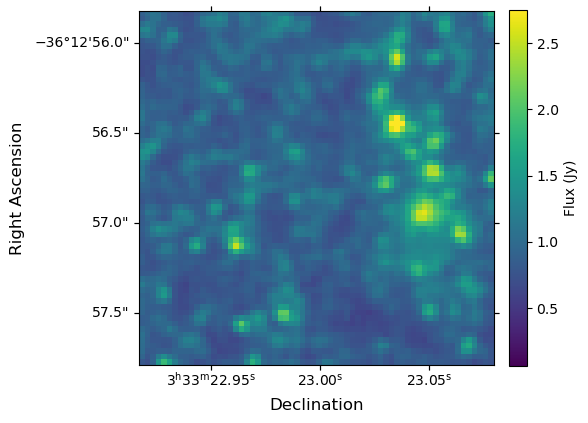

In [28]:
# Image pixel location of SN 83V taken from DS9
x = 3423
y = 7890

# x = round(1139)
# y = round(1244)
# Crop image with indexing to focus on SN -- for cropping, [y,x]
window = 32
y0 = y-window
y1 = y+window
x0 = x-window
x1 = x+window

# Crop region (same as before)
crop_small = (slice(y0, y1), slice(x0, x1))

# Set figure space
fig = plt.figure(figsize=(5,5))
ax = plt.subplot(projection = wcs_fk5)

# plot image in log space
miri770 = ax.imshow(nir_200_r[crop_small], norm='linear', vmax=2.75, vmin=0.06)

# axis labels and params
ax.set_ylabel('Right Ascension', fontsize = 12)
ax.set_xlabel('Declination', fontsize =12)

# colorbar
plt.colorbar(miri770, label='Flux (Jy)', fraction=0.046, pad=0.04)

plt.show()




In [21]:
# Reproject other images onto the reference WCS
nir_300_reproj, _ = reproject_interp((nir_300_r, nir_300_hdu[0].header), wcs_fk5)
nir_335_reproj, _ = reproject_interp((nir_335_r, nir_335_hdu[0].header), wcs_fk5)
nir_360_reproj, _ = reproject_interp((nir_360_r, nir_360_hdu[0].header), wcs_fk5)


Set OBSGEO-B to   -29.436458 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645548163.890 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.430943 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645470550.812 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.445500 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645675371.927 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


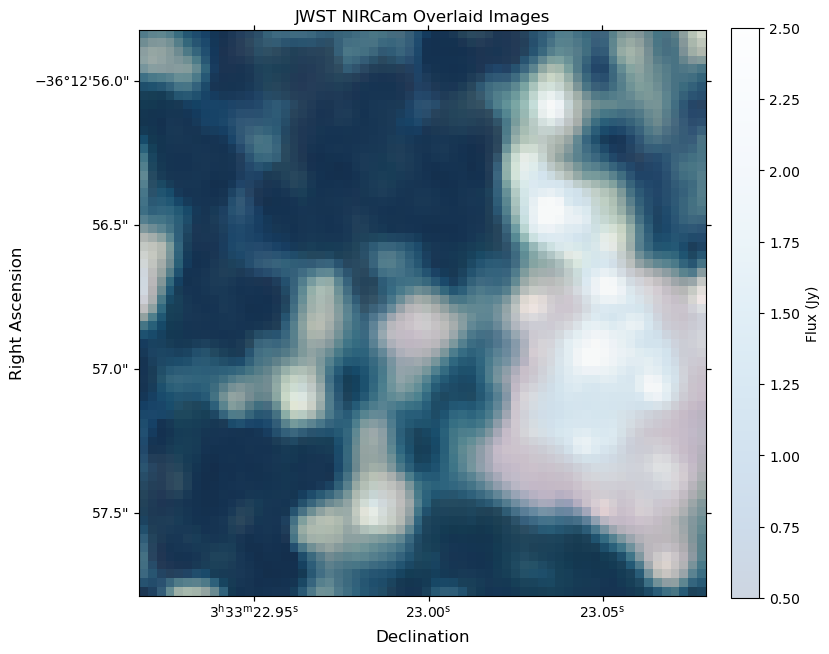

In [22]:
# plot MIRI image overlay in all filters
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs_200)

inorm0 = 'linear'
ivmin0 = 0.001
ivmax0 = 1.5

# Overlay images with transparency and different colormaps
ax.imshow(nir_300_reproj[crop_small], norm=inorm0, cmap='Reds_r', alpha=1, vmin=0.5, vmax=0.9)
ax.imshow(nir_335_reproj[crop_small], norm=inorm0, cmap='Greens_r', alpha=0.6, vmin=0.5, vmax=0.9)
ax.imshow(nir_360_reproj[crop_small], norm=inorm0, cmap='Blues_r', alpha=0.5, vmin=0.5, vmax=0.7)
base = ax.imshow(nir_200_r[crop_small], norm=inorm0, cmap='Blues_r', alpha=0.2, vmin=0.5, vmax=2.5)

ax.set_ylabel('Right Ascension', fontsize=12)
ax.set_xlabel('Declination', fontsize=12)
plt.colorbar(base, label='Flux (Jy)', fraction=0.046, pad=0.04)
plt.title('JWST NIRCam Overlaid Images')
plt.show()

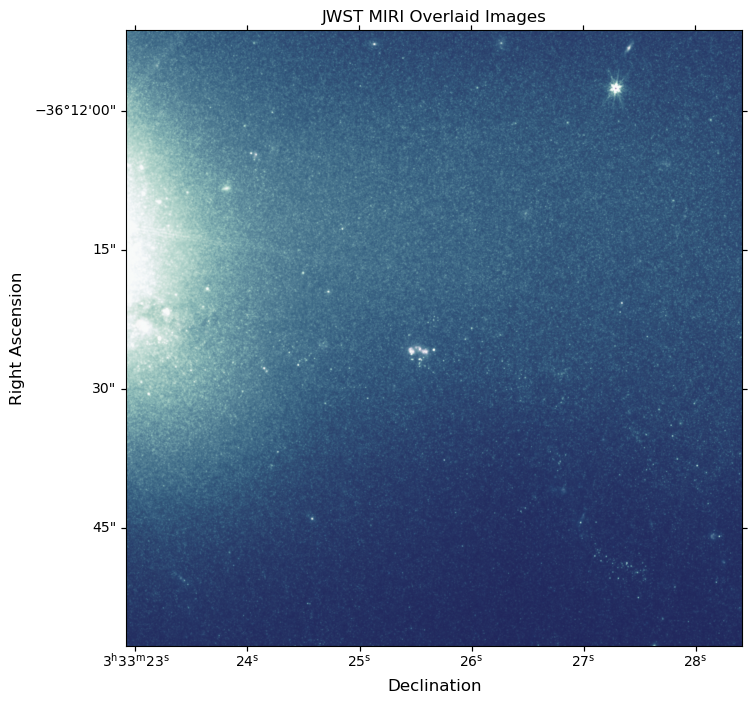

In [24]:
# plot MIRI image overlay in all filters
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs_200)

centerx = 3899 #3423
centery = 8417 #7890

xsize = 2164
ysize = 2164

x0 = centerx - xsize//2
x1 = centerx + xsize//2
y0 = centery - ysize//2
y1 = centery + ysize//2

crop_big = (slice(y0, y1), slice(x0, x1))
inorm1 = 'linear'
ivmin1 = 0.1
ivmax1 = 8

# Overlay images with transparency and different colormaps
ax.imshow(np.fliplr(nir_300_reproj[crop_big]), norm=inorm1, cmap='Reds_r', alpha=1, vmin=ivmin1, vmax=ivmax1)
ax.imshow(np.fliplr(nir_335_reproj[crop_big]), norm=inorm1, cmap='Greens_r', alpha=0.9, vmin=ivmin1, vmax=ivmax1)
ax.imshow(np.fliplr(nir_360_reproj[crop_big]), norm=inorm1, cmap='Blues_r', alpha=0.5, vmin=ivmin1, vmax=ivmax1)
base = ax.imshow(np.fliplr(nir_200_r[crop_big]), norm=inorm1, cmap='Purples_r', alpha=0.4, vmin=ivmin1, vmax=ivmax1)

ax.set_ylabel('Right Ascension', fontsize=12)
ax.set_xlabel('Declination', fontsize=12)
# plt.colorbar(base, label='Flux (Jy)', fraction=0.046, pad=0.04)
plt.title('JWST MIRI Overlaid Images')
plt.show()

In [17]:
# Convert FK4 to FK5
wcs_fk5 = wcs_200.deepcopy()
wcs_fk5.wcs.equinox = 2000.0
wcs_fk5.wcs.ctype = ['RA---TAN', 'DEC--TAN']
wcs_fk5.wcs.radesys = 'ICRS'

print(wcs_fk5.wcs.radesys)  # Should output 'ICRS' or 'FK5'
print(wcs_fk5.wcs.equinox)  # Should be 2000.0

ICRS
2000.0


/var/folders/q3/hykz569d1r1c51lc9dq_8cb00000gn/T/ipykernel_6552/4145610427.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


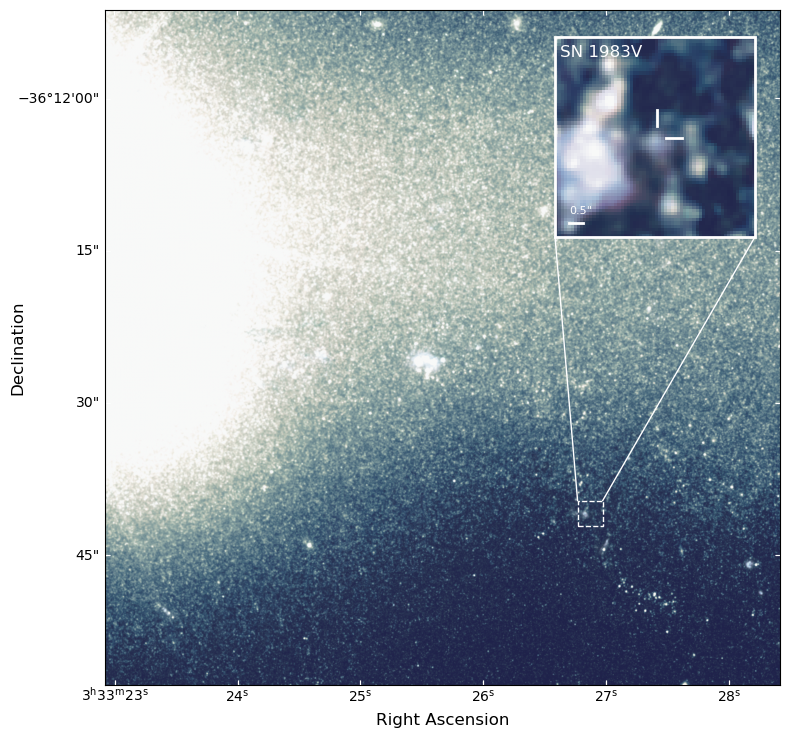

In [83]:
# Create the main figure
fig = plt.figure(figsize=(8, 8))

##################################
# BIG IMAGE (Main panel)
main_ax = fig.add_subplot(1, 1, 1, projection=wcs_fk5)

ivmin1 = 0.5 #0.1
ivmax1 = 2 #8

# Overlay main image
main_ax.imshow(np.fliplr(nir_360_reproj[crop_big]), norm=inorm1, cmap='Reds_r', alpha=1, vmin=ivmin1, vmax=ivmax1)
main_ax.imshow(np.fliplr(nir_335_reproj[crop_big]), norm=inorm1, cmap='Greens_r', alpha=0.6, vmin=ivmin1, vmax=ivmax1)
main_ax.imshow(np.fliplr(nir_300_reproj[crop_big]), norm=inorm1, cmap='Blues_r', alpha=0.5, vmin=ivmin1, vmax=ivmax1)
main_ax.imshow(np.fliplr(nir_200_r[crop_big]), norm=inorm1, cmap='Purples_r', alpha=0.2, vmin=ivmin1, vmax=ivmax1)

main_ax.set_xlabel('Right Ascension', fontsize=12)
main_ax.set_ylabel('Declination', fontsize=12, labelpad=0.00001)
main_ax.tick_params(axis='both', direction='in', color='white')

# main_ax.text(440, 940, 'A', fontsize=40, color='black')


##################################
# ZOOM IN

# Define inset position in figure fraction coordinates
inset_bounds = [0.7, 0.665, 0.25, 0.25]  # [left, bottom, width, height] in fig coordinates
inset_ax = WCSAxes(fig, inset_bounds, wcs=wcs_fk5)
fig.add_axes(inset_ax)

rect = plt.Rectangle(
    (0.7, 0.665),   # lower left in figure coords
    0.25, 0.25,     # width, height
    transform=fig.transFigure,            # use figure coords
    edgecolor="white",                   # border color
    facecolor="none",
    linewidth=2,
    zorder=10
)

fig.patches.append(rect)
# Remove coordinate ticks and labels from inset axes
inset_ax.coords[0].set_ticks_visible(False)
inset_ax.coords[1].set_ticks_visible(False)
inset_ax.coords[0].set_ticklabel_visible(False)
inset_ax.coords[1].set_ticklabel_visible(False)

# Optional: turn off grid if it's on
inset_ax.grid(False)

ivmin2 = 0.5
ivmax2 = 0.9
inset_ax.imshow(np.fliplr(nir_360_reproj[crop_small]), norm=inorm0, cmap='Reds_r', alpha=1, vmin=ivmin2, vmax=ivmax2)
inset_ax.imshow(np.fliplr(nir_335_reproj[crop_small]), norm=inorm0, cmap='Greens_r', alpha=0.6, vmin=ivmin2, vmax=ivmax2)
inset_ax.imshow(np.fliplr(nir_300_reproj[crop_small]), norm=inorm0, cmap='Blues_r', alpha=0.5, vmin=ivmin2, vmax=ivmax2)
inset_ax.imshow(np.fliplr(nir_200_r[crop_small]), norm=inorm0, cmap='Purples_r', alpha=0.2, vmin=ivmin2, vmax=2.5)

# ##################################
inset_ax.text(1, 57, 'SN 1983V', fontsize=12, color='white')
# # inset_ax.text(1, 1, 'B', fontsize=24, color='black')

##################################
# zoom in box
# Define zoom box coordinates
x1, y1 = 1515, 510
zoom_width = 80
zoom_height = 80

main_ax.add_patch(Rectangle((x1, y1), width=zoom_width, height=zoom_height,
                            edgecolor='white', facecolor='none',linestyle='--'))

##################################
# Crosshairs in zoom inset
window = 30  # adjust if needed
hx_line = [(window)+5, (window)+10]
hy_line = [(window+1), (window+1)]
vx_line = [(window+2), (window+2)]
vy_line = [(window)+5, (window)+10]

inset_ax.plot(hx_line, hy_line, color='white', linewidth=2)
inset_ax.plot(vx_line, vy_line, color='white', linewidth=2)
# ##################################
# Scale bar
x0, y0 = 4, 4
sc_x = [x0, x0+4.5]
sc_y = [y0, y0]

inset_ax.plot(sc_x, sc_y, color='white', linewidth=2)
inset_ax.text(x0, y0 + 3, '0.5"', fontsize=8, color='white')

# ##################################
# Connection lines
zoom_x, zoom_y = x1, y1 + zoom_height

# Match to corners of inset (bottom left and top left)
con1 = ConnectionPatch(xyA=(0, 0), coordsA=inset_ax.transAxes,
                       xyB=(zoom_x, zoom_y), coordsB=main_ax.transData,
                       color='white')
con2 = ConnectionPatch(xyA=(1, 0.0), coordsA=inset_ax.transAxes,
                       xyB=(zoom_x+zoom_width, y1+zoom_width), coordsB=main_ax.transData,
                       color='white')
fig.add_artist(con1)
fig.add_artist(con2)

##################################

# Done
plt.tight_layout()
plt.savefig("/Users/sophiakressy/Desktop/NIRCam_SN1983V_zoom.pdf", dpi=300)
plt.show()

# Plot MIRI Images Overlaid

In [2]:
# Load the FITS files
path = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/lvl_3/'
nir1 = 'jw02107-o021_t003_nircam_clear-f200w_jhat_i2d.fits'
nir2 = 'jw02107-o021_t003_nircam_clear-f300m_jhat_i2d.fits'
nir3 = 'jw02107-o021_t003_nircam_clear-f335m_jhat_i2d.fits'
nir4 = 'jw02107-o021_t003_nircam_clear-f360m_jhat_i2d.fits'
nir_files = [path+nir1, path+nir2,path+nir3, path+nir4]



In [3]:
# (This can all be streamlined later)

# Open all fits images
nir1_hdu = fits.open(nir_files[0])
nir2_hdu = fits.open(nir_files[1])
nir3_hdu = fits.open(nir_files[2])
nir4_hdu = fits.open(nir_files[3])

# reference image for other images to reproject on
# recommend that this ref image is the highest resolution of the group.
nir_200_data   = nir1_hdu[1].data
nir_200_header = nir1_hdu[1].header
wcs = WCS(nir1_hdu[1].header)
print(wcs)

# grab rest of data
nir_300_data   = nir2_hdu[1].data
nir_335_data   = nir3_hdu[1].data
nir_360_data   = nir4_hdu[1].data


# miri_hdu.info()
# plt.imshow(miri_770_data)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 53.393777943493 -36.144449132842 
CRPIX : 2272.9862103196 4176.2381151845 
PC1_1 PC1_2  : 0.15021981105671 -0.98873676953515 
PC2_1 PC2_2  : -0.98876322921199 -0.15017986305483 
CDELT : 8.5411386840331e-06 8.5411386840331e-06 
NAXIS : 4562  8385


Set DATE-AVG to '2022-08-13T18:06:02.506' from MJD-AVG.
Set DATE-END to '2022-08-13T19:05:49.676' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.445500 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645675371.927 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [4]:
# Handle Nans; set Nans to 0
nir_200_data[np.isnan(nir_200_data)] = 0
nir_300_data[np.isnan(nir_300_data)] = 0
nir_335_data[np.isnan(nir_335_data)] = 0
nir_360_data[np.isnan(nir_360_data)] = 0

# How to handle negative values? Not sure. Going to set to 0
nir_200_data[nir_200_data<0] = 0.01
nir_300_data[nir_300_data<0] = 0.01
nir_335_data[nir_335_data<0] = 0.01
nir_360_data[nir_360_data<0] = 0.01

## Sanity Check

(8385, 4562)


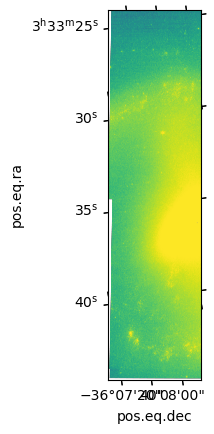

In [ ]:
# plot 770 as an example, make sure something appears!
# miri_770_flipped = np.flip(miri_770_data, axis=0)
fig = plt.figure()
ax = plt.subplot(projection = wcs)
ax.imshow(nir_200_data[0:8000,0:2000],norm='log', vmin=0.01, vmax=4)
print(np.shape(nir_200_data))

## Establish Zoomed-in region coords; 200 as ref pic; Sanity check

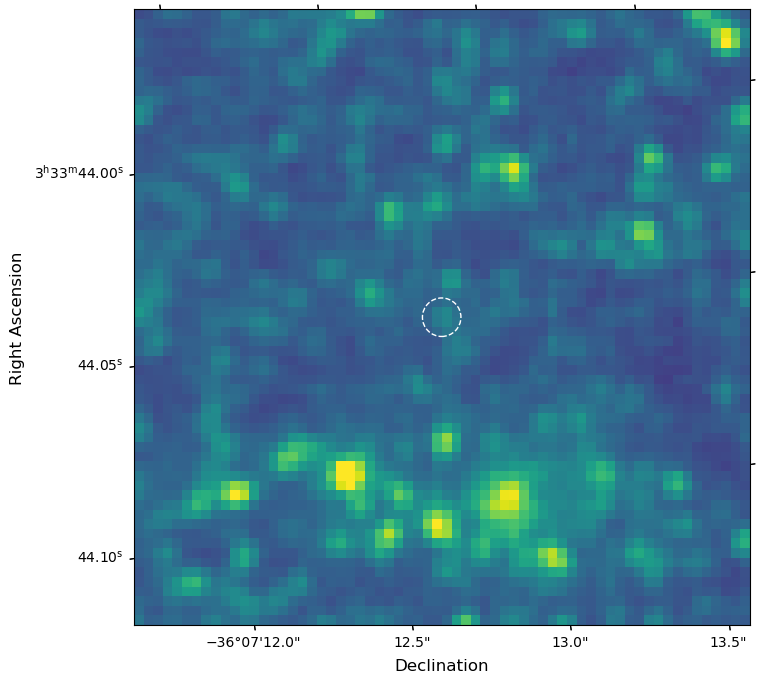

In [139]:
# Image pixel location of SN 83V taken from DS9
x = 2591
y = 5376
# Crop image with indexing to focus on SN -- for cropping, [y,x]
window = 32 # for 200, 32 pixels = 1"
y0 = y-window
y1 = y+window
x0 = x-window
x1 = x+window

# Crop region (same as before)
crop_small = (slice(y0, y1), slice(x0, x1))
crop = (slice(x0, x1), slice(y0, y1))

# Set figure space
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(projection = wcs)

# plot image in log space
miri770 = ax.imshow(nir_200_data[crop_small], norm='linear', vmax=2.75, vmin=0.06)

# plot circle to find SN
ax.add_patch(plt.Circle((window-0.5,window-0.5), radius=2, color='white', linestyle= '--', fill=False))


# axis labels and params
ax.set_ylabel('Right Ascension', fontsize = 12)
ax.set_xlabel('Declination', fontsize =12)

# colorbar
# plt.colorbar(miri770, label='Flux (Jy)', fraction=0.046, pad=0.04)

plt.show()

# Extra plotting tricks if need later
# ax.tick_params(axis='x', labelsize=12, direction="in", color = 'white', width = 1, length = 7)
# ax.tick_params(axis='y', labelsize=12, direction="in", color = 'white', width = 1, length = 7)





## Reproject other filters onto 770

In [27]:
# Reproject other images onto the reference WCS
nir_300_reproj, _ = reproject_interp((nir_300_data, nir2_hdu[1].header), nir_200_header)
nir_335_reproj, _ = reproject_interp((nir_335_data, nir3_hdu[1].header), nir_200_header)
nir_360_reproj, _ = reproject_interp((nir_360_data, nir4_hdu[1].header), nir_200_header)


Set DATE-AVG to '2022-08-13T18:12:21.004' from MJD-AVG.
Set DATE-END to '2022-08-13T18:49:54.093' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.436458 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645548163.890 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-08-13T18:06:02.506' from MJD-AVG.
Set DATE-END to '2022-08-13T19:05:49.676' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.445500 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645675371.927 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-08-13T18:28:16.595' from MJD-AVG.
Set DATE-END to '2022-08-13T19:05:49.676' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.430943 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645470550.812 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-08-13T17:51:46.246' from MJD-AVG.
Set DATE-END to '2022-08-13T18:34:30.702' from MJD-END'. [astropy.wcs.wcs]


## Plot zoomed-in region in Linear

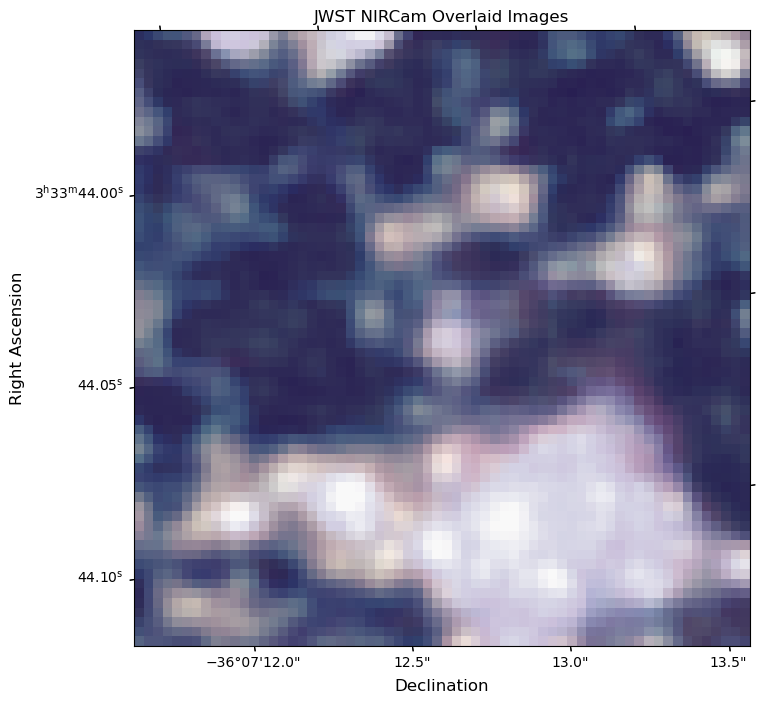

In [152]:
# plot MIRI image overlay in all filters
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs)

inorm0 = 'linear'
ivmin0 = 0.001
ivmax0 = 1.5


# Overlay images with transparency and different colormaps
ax.imshow(nir_360_reproj[crop_small], norm=inorm0, cmap='Reds_r', alpha=1, vmin=0.5, vmax=0.9)#2.77
ax.imshow(nir_335_reproj[crop_small], norm=inorm0, cmap='Greens_r', alpha=0.5, vmin=0.5, vmax=0.9) #2.95
ax.imshow(nir_300_reproj[crop_small], norm=inorm0, cmap='Blues_r', alpha=0.5, vmin=0.5, vmax=0.7) #2.75
ax.imshow(nir_200_data[crop_small], norm=inorm0, cmap='Purples_r', alpha=0.3, vmin=0.5, vmax=2.5)#2.75

ax.set_ylabel('Right Ascension', fontsize=12)
ax.set_xlabel('Declination', fontsize=12)
# plt.colorbar(base, label='Flux (Jy)', fraction=0.046, pad=0.04)
plt.title('JWST NIRCam Overlaid Images')
plt.show()

## Linear Zoom-out of Galaxy

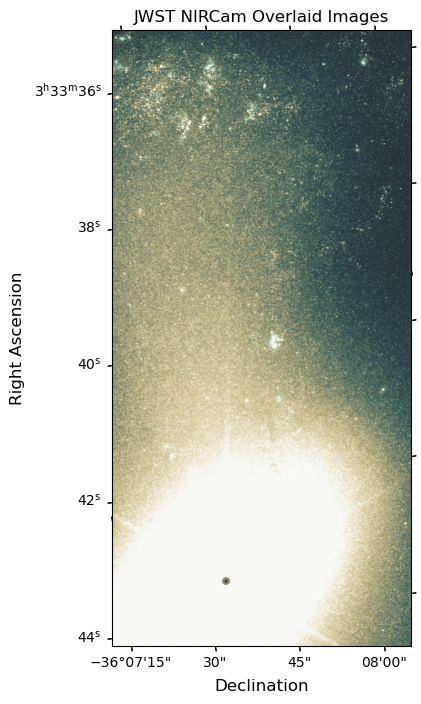

In [138]:
# plot MIRI image overlay in all filters
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs)

crop_big = (slice(3000, 6600), slice(1250, 3000))
inorm1 = 'linear'
ivmin1 = .06
ivmax1 = 2.75

# Overlay images with transparency and different colormaps
ax.imshow(nir_360_reproj[crop_big], norm=inorm1, cmap='Reds_r', alpha=1, vmin=0.5, vmax=ivmax1)
ax.imshow(nir_335_reproj[crop_big], norm=inorm1, cmap='Oranges_r', alpha=0.9, vmin=0.5, vmax=ivmax1)
ax.imshow(nir_300_reproj[crop_big], norm=inorm1, cmap='Greens_r', alpha=0.5, vmin=0.5, vmax=ivmax1)
base = ax.imshow(nir_200_data[crop_big], norm=inorm1, cmap='Blues_r', alpha=0.4, vmin=0.5, vmax=ivmax1)

ax.set_ylabel('Right Ascension', fontsize=12)
ax.set_xlabel('Declination', fontsize=12)
# plt.colorbar(base, label='Flux (Jy)', fraction=0.046, pad=0.04)
plt.title('JWST NIRCam Overlaid Images')
plt.show()

In [229]:
# # image = make_lupton_rgb(miri_2100_reproj[crop], miri_1000_reproj[crop], miri_770_data[crop], stretch=4, Q=6)
# r = nir_360_reproj[crop_big]
# g = nir_335_reproj[crop_big]
# b = nir_300_reproj[crop_big]
# image = make_lupton_rgb(r, g, b, stretch=5)

# fig = plt.figure(figsize=(16,10))#figsize=(8,8)
# ax = plt.subplot(projection = wcs)
# ax.set_ylabel('Right Ascension', fontsize=12)
# ax.set_xlabel('Declination', fontsize=12)
# plt.title('JWST MIRI Overlaid Images')
# ax.imshow(image)



# Zoomed-in MIRI

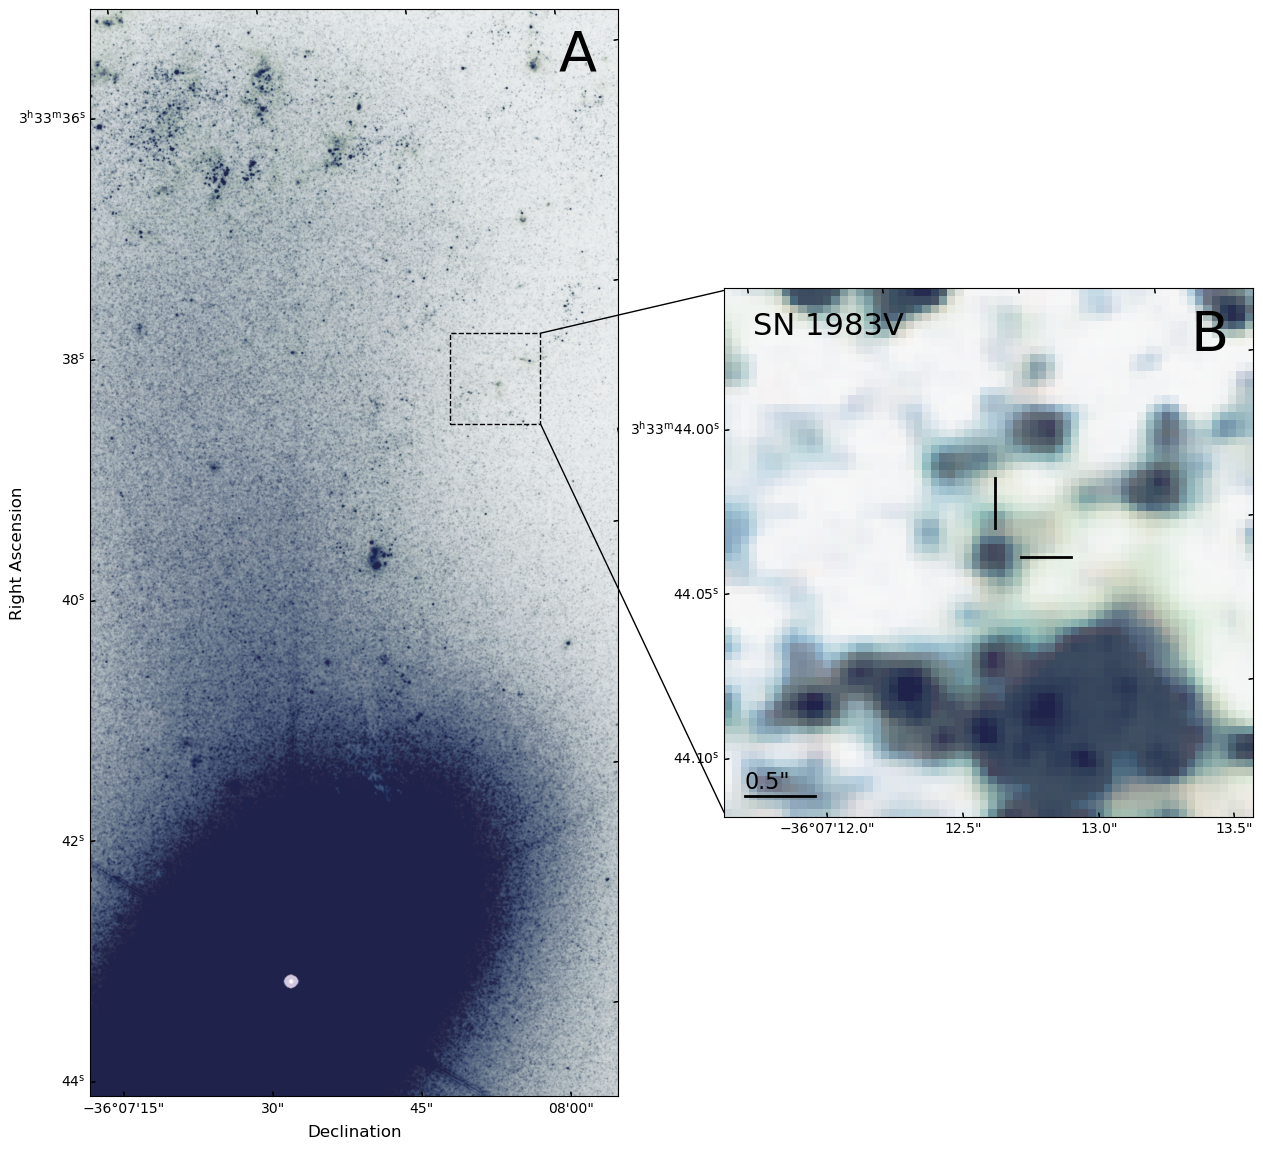

In [ ]:
fig = plt.figure(figsize=(15, 15))

#############
# TOP SMALL SQUARE
sub1 = fig.add_subplot(1,2,2, projection = wcs) # one rows, two columns, second cell

# Overlay images with transparency and different colormaps
sub1.imshow(nir_360_reproj[crop_small], norm=inorm0, cmap='Reds', alpha=1, vmin=0.5, vmax=0.9)#2.77
sub1.imshow(nir_335_reproj[crop_small], norm=inorm0, cmap='Greens', alpha=0.6, vmin=0.5, vmax=0.9) #2.95
sub1.imshow(nir_300_reproj[crop_small], norm=inorm0, cmap='Blues', alpha=0.5, vmin=0.5, vmax=0.7) #2.75
sub1.imshow(nir_200_data[crop_small], norm=inorm0, cmap='Purples', alpha=0.2, vmin=0.5, vmax=2.5)#2.75

sub1.set_xlabel('', fontsize = 12)
sub1.set_ylabel('', fontsize = 12, labelpad = 0.0001)
sub1.tick_params(axis='x', direction='in')
sub1.tick_params(axis='y', direction='in')

#############
# BIG FIGURE
sub3 = fig.add_subplot(1,2,1, projection = wcs) # one rows, two columns, first cell

# Overlay images with transparency and different colormaps
sub3.imshow(nir_360_reproj[crop_big], norm=inorm1, cmap='Reds', alpha=1, vmin=ivmin1, vmax=ivmax1)
sub3.imshow(nir_335_reproj[crop_big], norm=inorm1, cmap='Greens', alpha=0.6, vmin=ivmin1, vmax=ivmax1)
sub3.imshow(nir_300_reproj[crop_big], norm=inorm1, cmap='Blues', alpha=0.5, vmin=ivmin1, vmax=ivmax1)
sub3.imshow(nir_200_data[crop_big], norm=inorm1, cmap='Purples', alpha=0.2, vmin=ivmin1, vmax=ivmax1)

sub3.set_xlabel('Declination', fontsize = 12)
sub3.set_ylabel('Right Ascension', fontsize = 12, labelpad = 0.0001)
sub3.tick_params(axis='x', direction='in')
sub3.tick_params(axis='y', direction='in')

# #############
# # Color bar
# # cbar = fig.colorbar(im, orientation='horizontal', pad = 0.1)
# # cbar.set_label(r"RHT $\theta$ ($^\circ$)", fontsize = 22)

# #############
# # Add Labels
sub3.text(1550, 3400, 'A', fontsize=40, color = 'black') #, fontweight = 'bold'
sub1.text(window*2-8, window*2-8, 'B', fontsize=40, color = 'black')

#############
# Add Zoom-in square (need to make this more generic); Plots with Bottom Left corner
# x1 = 53.3835165 # RA
# y1 = -36.1471056 # DEC

x1 = 1191 #2544
y1 = 2226 #5324
    
sub3.add_patch(plt.Rectangle((x1,y1), width = 300, height = 300, ls="--", color = 'black', fill=False))
    
#############
# Plot connecting lines
con1 = ConnectionPatch(xyA=(-0.5, (window*2)-0.75), coordsA=sub1.transData, 
                       xyB=(1491, 2526), coordsB=sub3.transData, color = 'black', linewidth = 1, alpha = 1)
fig.add_artist(con1)

con2 = ConnectionPatch(xyA=(-0.5, 0), coordsA=sub1.transData, 
                       xyB=(1491, 2226), coordsB=sub3.transData, color = 'black', linewidth = 1, alpha = 1)
fig.add_artist(con2)

#############
# Plot circle ID-ing SN in zoomed-in; Plots from center of circle
# x = window #149
# y = window #149
# sub1.add_patch(plt.Circle((x+0.25,y-1), radius=3, color='black', linestyle= '--', fill=False))

#############
# Plot cross hairs

hx_line = [(window-0.5)+4, (window-0.5)+10]
hy_line = [(window-1), (window-1)]

vx_line = [(window+0.25), (window+0.25)]
vy_line = [(window-0.5)+3, (window-0.5)+9]
sub1.plot(hx_line, hy_line, color='black', linewidth=2, linestyle='-')
sub1.plot(vx_line, vy_line, color='black', linewidth=2, linestyle='-')

#############
# Scale bar
x0 = 2
y0 = 2
sc_x = [x0, x0+8.5] # NIRCam = 0.5" = 8.5pixels
sc_y = [y0, y0]

sub1.plot(sc_x, sc_y, color='black', linewidth=2, linestyle='-')

#############
# Plot Text IDing
sub1.text(3, (window*2)-6, 'SN 1983V', fontsize=22, color = 'black')

sub1.text(2, 3, '0.5"', fontsize=16, color = 'black')

# # plt.tight_layout()

plt.savefig('/Users/sophiakressy/Desktop/NIRCam_83V_zoom.pdf')


In [ ]:
# TO DO

# * Location of SN in RA + Dec
# [3:33:31.6159, -36:08:55.222] #sexagesmial, IRCS
# [53.3817412, -36.1486795] # degrees, fk5
# [1140.0925, 1244.2278] # image, pixels

# * Crop image by just adjusting x and y axis length

# * fix X,Y labels

# * color bar

# * visually check orientation of galaxy

# * overlay other images

# * make it look nice with scaling

# overlay circle to label SN

# zoom in image, 50x50 pixels outside SN location seems good